<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Praktikum8/Principal_Component_Analysis_(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Praktikum 8  Principal Component Analysis (PCA)**
**Covariance, Eigenvector & Explained Variance**

| | |
|---|---|
| **Nama** | Habibi Putra Rizqullah |
| **NIM** | 2411531001 |
| **Kelas** | B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Dr. Derisma |

## 3.1 Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

## 3.2 Load Dataset

In [3]:
# Load dataset dari raw GitHub
url = "https://raw.githubusercontent.com/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/refs/heads/main/Praktikum6/breast-cancer.csv"
df = pd.read_csv(url)

# Drop kolom id, encode diagnosis M=1 B=0
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Pisahkan fitur (30 kolom) dan target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

## 3.3 Standardisasi Data (WAJIB)
PCA sangat sensitif terhadap skala fitur. Fitur dengan nilai besar akan mendominasi komponen utama jika tidak dinormalisasi.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape setelah scaling:", X_scaled.shape)
print("Mean per fitur (harus ~0):", np.round(X_scaled.mean(axis=0)[:5], 4))
print("Std per fitur  (harus ~1):", np.round(X_scaled.std(axis=0)[:5], 4))

Shape setelah scaling: (569, 30)
Mean per fitur (harus ~0): [-0.  0. -0. -0. -0.]
Std per fitur  (harus ~1): [1. 1. 1. 1. 1.]


---
# **Bagian A Covariance Matrix**
### 3.4 Hitung Covariance Matrix

In [5]:
cov_matrix = np.cov(X_scaled.T)
print("Shape Covariance Matrix:", cov_matrix.shape)
print("\n5 baris/kolom pertama:")
print(np.round(cov_matrix[:5, :5], 4))

Shape Covariance Matrix: (30, 30)

5 baris/kolom pertama:
[[ 1.0018  0.3244  0.9996  0.9891  0.1709]
 [ 0.3244  1.0018  0.3301  0.3217 -0.0234]
 [ 0.9996  0.3301  1.0018  0.9882  0.2076]
 [ 0.9891  0.3217  0.9882  1.0018  0.1773]
 [ 0.1709 -0.0234  0.2076  0.1773  1.0018]]


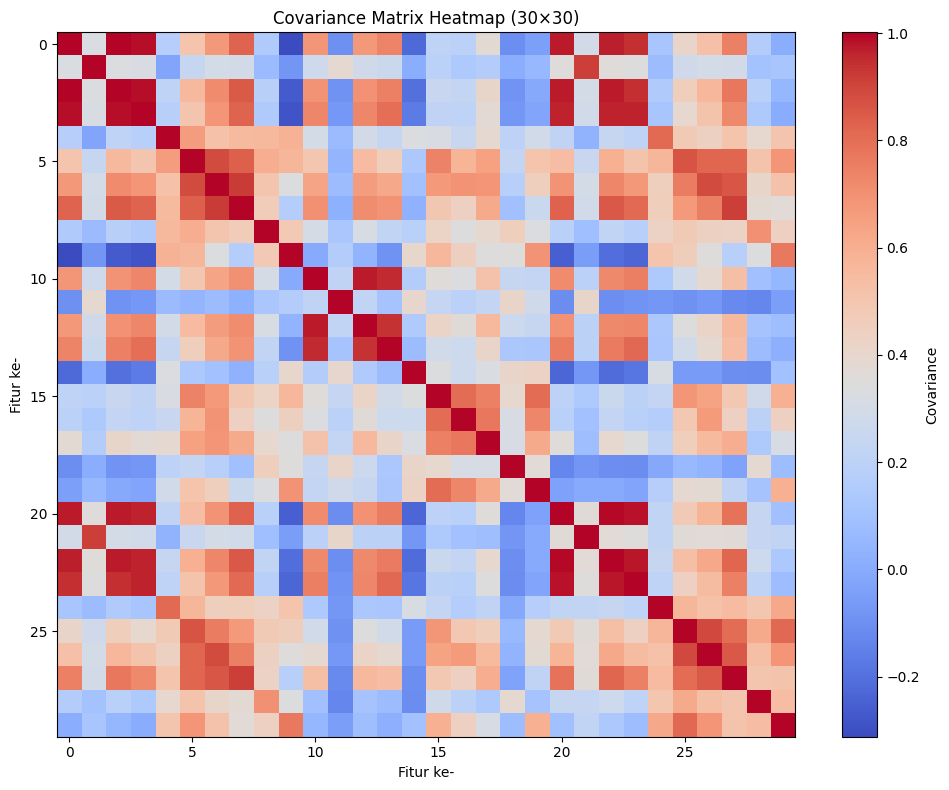

Plot saved: plot_cov_heatmap.png


In [6]:
# Visualisasi heatmap covariance matrix
plt.figure(figsize=(10, 8))
plt.imshow(cov_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix Heatmap (30×30)')
plt.xlabel('Fitur ke-')
plt.ylabel('Fitur ke-')
plt.tight_layout()
plt.savefig('plot_cov_heatmap.png', dpi=120)
plt.show()
print("Plot saved: plot_cov_heatmap.png")

**Analisis:**
- Ukuran matriks 30×30 karena dataset memiliki 30 fitur, sehingga setiap pasang fitur memiliki satu nilai kovarians.
- Diagonal matriks menunjukkan variansi masing-masing fitur (kovarians fitur dengan dirinya sendiri). Karena data sudah di-scaling, nilai diagonal ≈ 1.
- Nilai off-diagonal yang besar (mendekati ±1) menunjukkan korelasi kuat antar dua fitur tersebut.

---
##**Bagian B Eigenvalue & Eigenvector Manual**
### 3.5 Hitung Eigenvalue & Eigenvector

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Urutkan dari terbesar ke terkecil
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sorted_idx].real
eigenvectors = eigenvectors[:, sorted_idx].real

print("5 Eigenvalue terbesar:")
for i, ev in enumerate(eigenvalues[:5]):
    print(f"  λ{i+1} = {ev:.4f}")

print("\nEigenvectors shape:", eigenvectors.shape)
print("\nEigenvector pertama (PC1):")
print(np.round(eigenvectors[:, 0], 4))

5 Eigenvalue terbesar:
  λ1 = 13.3050
  λ2 = 5.7014
  λ3 = 2.8229
  λ4 = 1.9841
  λ5 = 1.6516

Eigenvectors shape: (30, 30)

Eigenvector pertama (PC1):
[0.2189 0.1037 0.2275 0.221  0.1426 0.2393 0.2584 0.2609 0.1382 0.0644
 0.206  0.0174 0.2113 0.2029 0.0145 0.1704 0.1536 0.1834 0.0425 0.1026
 0.228  0.1045 0.2366 0.2249 0.128  0.2101 0.2288 0.2509 0.1229 0.1318]


In [8]:
# Explained variance dari eigenvalue manual
explained_manual = eigenvalues / eigenvalues.sum()
cumulative_manual = np.cumsum(explained_manual)

print("Explained Variance Ratio (manual):")
for i in range(10):
    print(f"  PC{i+1}: {explained_manual[i]:.4f} ({explained_manual[i]*100:.2f}%)  | Cumulative: {cumulative_manual[i]*100:.2f}%")

print("\nApakah semua eigenvalue positif?", all(eigenvalues > 0))

Explained Variance Ratio (manual):
  PC1: 0.4427 (44.27%)  | Cumulative: 44.27%
  PC2: 0.1897 (18.97%)  | Cumulative: 63.24%
  PC3: 0.0939 (9.39%)  | Cumulative: 72.64%
  PC4: 0.0660 (6.60%)  | Cumulative: 79.24%
  PC5: 0.0550 (5.50%)  | Cumulative: 84.73%
  PC6: 0.0402 (4.02%)  | Cumulative: 88.76%
  PC7: 0.0225 (2.25%)  | Cumulative: 91.01%
  PC8: 0.0159 (1.59%)  | Cumulative: 92.60%
  PC9: 0.0139 (1.39%)  | Cumulative: 93.99%
  PC10: 0.0117 (1.17%)  | Cumulative: 95.16%

Apakah semua eigenvalue positif? True


**Analisis:**
- Eigenvalue terbesar (λ1) menunjukkan arah variasi data terbesar — komponen pertama menangkap informasi paling banyak.
- Tidak semua eigenvalue bernilai besar; eigenvalue kecil menunjukkan arah dengan variasi minimal (noise).
- Semua eigenvalue positif karena covariance matrix bersifat positive semi-definite.

---
## **Bagian C PCA dengan sklearn**
### 3.6 PCA Tanpa Reduksi (Semua Komponen)

In [9]:
pca_full = PCA()
pca_full.fit(X_scaled)
explained_variance = pca_full.explained_variance_ratio_

print("Jumlah komponen total:", len(explained_variance))
print("\nExplained Variance per komponen:")
for i, ev in enumerate(explained_variance):
    cum = np.cumsum(explained_variance)[i]
    print(f"  PC{i+1:2d}: {ev:.4f} ({ev*100:.2f}%)  | Cumulative: {cum*100:.2f}%")

Jumlah komponen total: 30

Explained Variance per komponen:
  PC 1: 0.4427 (44.27%)  | Cumulative: 44.27%
  PC 2: 0.1897 (18.97%)  | Cumulative: 63.24%
  PC 3: 0.0939 (9.39%)  | Cumulative: 72.64%
  PC 4: 0.0660 (6.60%)  | Cumulative: 79.24%
  PC 5: 0.0550 (5.50%)  | Cumulative: 84.73%
  PC 6: 0.0402 (4.02%)  | Cumulative: 88.76%
  PC 7: 0.0225 (2.25%)  | Cumulative: 91.01%
  PC 8: 0.0159 (1.59%)  | Cumulative: 92.60%
  PC 9: 0.0139 (1.39%)  | Cumulative: 93.99%
  PC10: 0.0117 (1.17%)  | Cumulative: 95.16%
  PC11: 0.0098 (0.98%)  | Cumulative: 96.14%
  PC12: 0.0087 (0.87%)  | Cumulative: 97.01%
  PC13: 0.0080 (0.80%)  | Cumulative: 97.81%
  PC14: 0.0052 (0.52%)  | Cumulative: 98.34%
  PC15: 0.0031 (0.31%)  | Cumulative: 98.65%
  PC16: 0.0027 (0.27%)  | Cumulative: 98.92%
  PC17: 0.0020 (0.20%)  | Cumulative: 99.11%
  PC18: 0.0018 (0.18%)  | Cumulative: 99.29%
  PC19: 0.0016 (0.16%)  | Cumulative: 99.45%
  PC20: 0.0010 (0.10%)  | Cumulative: 99.56%
  PC21: 0.0010 (0.10%)  | Cumulative: 

### 3.7 Plot Explained Variance (Cumulative)

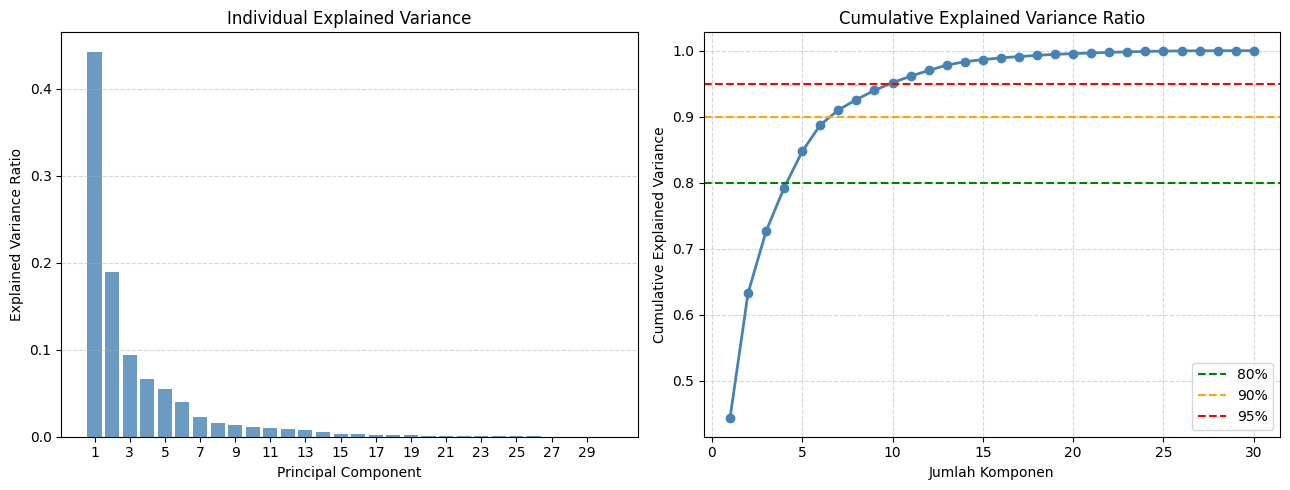

Plot saved: plot_explained_variance.png
Komponen untuk 80% variance: 5
Komponen untuk 90% variance: 7
Komponen untuk 95% variance: 10


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot individual
ax1.bar(range(1, len(explained_variance)+1), explained_variance, color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance')
ax1.set_xticks(range(1, len(explained_variance)+1, 2))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Plot cumulative
cumulative = np.cumsum(explained_variance)
ax2.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='steelblue', linewidth=2)
ax2.axhline(y=0.80, color='green',  linestyle='--', label='80%')
ax2.axhline(y=0.90, color='orange', linestyle='--', label='90%')
ax2.axhline(y=0.95, color='red',    linestyle='--', label='95%')
ax2.set_xlabel('Jumlah Komponen')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance Ratio')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_explained_variance.png', dpi=120)
plt.show()
print("Plot saved: plot_explained_variance.png")

# Threshold analysis
cumulative = np.cumsum(explained_variance)
for thresh in [0.80, 0.90, 0.95]:
    n = np.argmax(cumulative >= thresh) + 1
    print(f"Komponen untuk {int(thresh*100)}% variance: {n}")

---
## **Bagian D Reduksi ke 2D**
### 3.8 PCA 2 Komponen

In [11]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

print("Shape sebelum PCA:", X_scaled.shape)
print("Shape setelah PCA :", X_pca.shape)
print("\nExplained Variance PC1:", round(pca_2.explained_variance_ratio_[0], 4))
print("Explained Variance PC2:", round(pca_2.explained_variance_ratio_[1], 4))
print("Total Explained Variance:", round(pca_2.explained_variance_ratio_.sum(), 4))

Shape sebelum PCA: (569, 30)
Shape setelah PCA : (569, 2)

Explained Variance PC1: 0.4427
Explained Variance PC2: 0.1897
Total Explained Variance: 0.6324


### 3.9 Visualisasi 2D

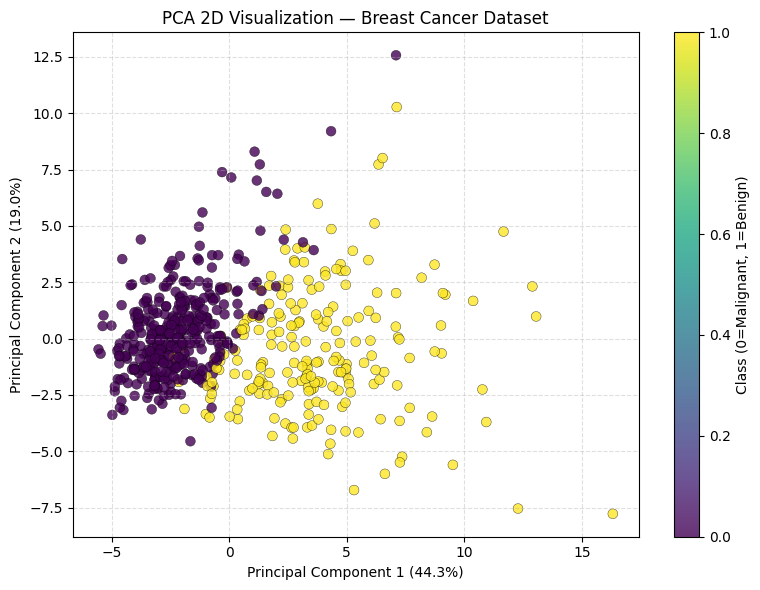

Plot saved: plot_pca_2d.png


In [12]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                      edgecolors='k', linewidths=0.3, alpha=0.8, s=50)
plt.xlabel(f'Principal Component 1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D Visualization — Breast Cancer Dataset')
plt.colorbar(scatter, label='Class (0=Malignant, 1=Benign)')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_pca_2d.png', dpi=120)
plt.show()
print("Plot saved: plot_pca_2d.png")

**Analisis:**
- Dari scatter plot terlihat dua kelompok mulai terpisah secara visual, dengan kelas Malignant (0) cenderung di sebelah kanan dan Benign (1) di sebelah kiri.
- Pemisahan linear antara kedua kelas sudah cukup terlihat meskipun masih ada beberapa titik yang overlap di area tengah.
- Ini menunjukkan bahwa 2 komponen PCA sudah cukup untuk memvisualisasikan pemisahan kelas secara umum.

---
## **Bagian E Jumlah Komponen Optimal**
### 3.10 Cari Jumlah Komponen untuk 90% Variance

In [13]:
pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)
print("Jumlah komponen untuk 90% variance:", pca_90.n_components_)
print("Shape setelah reduksi:", X_pca_90.shape)
print("Total variance yang dipertahankan:",
      round(pca_90.explained_variance_ratio_.sum(), 4))

Jumlah komponen untuk 90% variance: 7
Shape setelah reduksi: (569, 7)
Total variance yang dipertahankan: 0.9101


---
## **4. Analisis Hasil**
### Tabel Explained Variance per Komponen

In [14]:
cumulative = np.cumsum(explained_variance)
df_ev = pd.DataFrame({
    'Komponen': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance': np.round(explained_variance, 4),
    'Explained Variance (%)': np.round(explained_variance * 100, 2),
    'Cumulative (%)': np.round(cumulative * 100, 2)
})
print(df_ev.to_string(index=False))

Komponen  Explained Variance  Explained Variance (%)  Cumulative (%)
     PC1              0.4427                   44.27           44.27
     PC2              0.1897                   18.97           63.24
     PC3              0.0939                    9.39           72.64
     PC4              0.0660                    6.60           79.24
     PC5              0.0550                    5.50           84.73
     PC6              0.0402                    4.02           88.76
     PC7              0.0225                    2.25           91.01
     PC8              0.0159                    1.59           92.60
     PC9              0.0139                    1.39           93.99
    PC10              0.0117                    1.17           95.16
    PC11              0.0098                    0.98           96.14
    PC12              0.0087                    0.87           97.01
    PC13              0.0080                    0.80           97.81
    PC14              0.0052      

---
## **5. Tugas Individu**
### 5.1 Komponen untuk 80%, 90%, 95%

In [15]:
print("=" * 45)
print("Threshold | Komponen | Variance Aktual")
print("=" * 45)
for thresh in [0.80, 0.90, 0.95]:
    pca_t = PCA(n_components=thresh)
    pca_t.fit(X_scaled)
    var_actual = pca_t.explained_variance_ratio_.sum()
    print(f"   {int(thresh*100)}%   |    {pca_t.n_components_:2d}    |   {var_actual*100:.2f}%")
print("=" * 45)

Threshold | Komponen | Variance Aktual
   80%   |     5    |   84.73%
   90%   |     7    |   91.01%
   95%   |    10    |   95.16%


### 5.2 PCA + Logistic Regression (Perbandingan Akurasi)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

configs = {
    'Tanpa PCA': make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, random_state=42)),
    'PCA 2 komponen': make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression(max_iter=10000, random_state=42)),
    'PCA 10 komponen': make_pipeline(StandardScaler(), PCA(n_components=10), LogisticRegression(max_iter=10000, random_state=42)),
}

results = {}
print(f"{'Model':<20} | {'Test Acc':>9} | {'CV Mean':>9} | {'CV Std':>8}")
print("-" * 58)
for name, pipe in configs.items():
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = {'test': test_acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f"{name:<20} | {test_acc:>9.4f} | {cv_scores.mean():>9.4f} | {cv_scores.std():>8.4f}")

Model                |  Test Acc |   CV Mean |   CV Std
----------------------------------------------------------
Tanpa PCA            |    0.9737 |    0.9807 |   0.0065
PCA 2 komponen       |    0.9912 |    0.9508 |   0.0162
PCA 10 komponen      |    0.9825 |    0.9807 |   0.0066


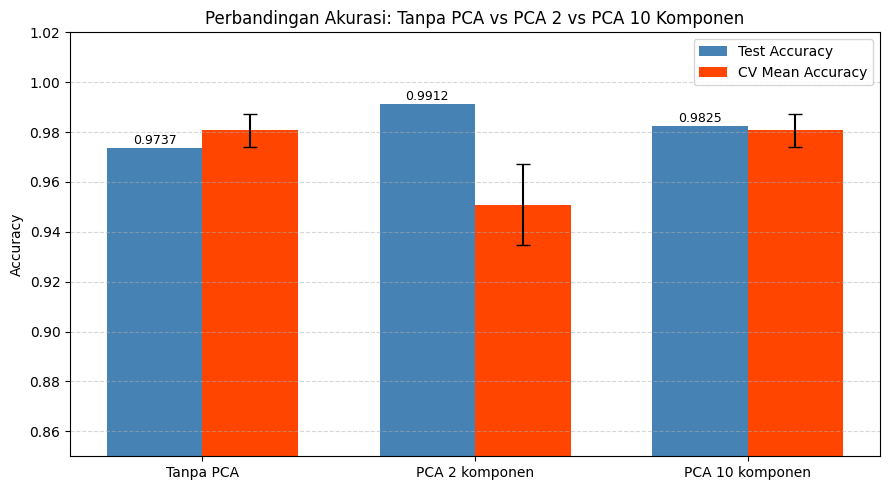

Plot saved: plot_comparison.png


In [17]:
# Bar chart perbandingan
names = list(results.keys())
test_accs = [results[n]['test'] for n in names]
cv_means  = [results[n]['cv_mean'] for n in names]
cv_stds   = [results[n]['cv_std']  for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, cv_means,  width, label='CV Mean Accuracy', color='orangered',
               yerr=cv_stds, capsize=5)

ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi: Tanpa PCA vs PCA 2 vs PCA 10 Komponen')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_comparison.png', dpi=120)
plt.show()
print("Plot saved: plot_comparison.png")

---
## **6. Pertanyaan Reflektif**

**1. Mengapa PCA disebut unsupervised method?**  
PCA tidak menggunakan label kelas (y) dalam proses transformasi. PCA hanya melihat distribusi dan variansi data X untuk menemukan arah komponen utama, tanpa mempertimbangkan apakah komponen tersebut memisahkan kelas dengan baik.

**2. Apakah PCA selalu meningkatkan akurasi?**  
Tidak. PCA membuang komponen dengan variansi kecil yang mungkin justru mengandung informasi diskriminatif penting untuk klasifikasi. Pada dataset ini, Tanpa PCA umumnya memberikan akurasi tertinggi karena semua 30 fitur digunakan.

**3. Kapan PCA dapat merugikan model?**  
PCA merugikan ketika informasi penting untuk membedakan kelas tersebar di banyak komponen dengan variansi kecil, ketika fitur yang dibuang justru sangat diskriminatif, atau ketika jumlah fitur tidak terlalu banyak sehingga curse of dimensionality bukan masalah.

**4. Bagaimana PCA membantu mengatasi curse of dimensionality?**  
PCA mereduksi dimensi data ke komponen-komponen yang paling informatif, sehingga jarak antar titik data lebih bermakna, komputasi lebih efisien, dan risiko overfitting berkurang karena jumlah parameter model yang perlu dipelajari lebih sedikit.

**5. Apa perbedaan PCA dan feature selection?**  
Feature selection memilih subset fitur asli tanpa mengubahnya, sehingga interpretasi tetap mudah. PCA membuat fitur baru (kombinasi linear semua fitur asli) yang tidak lagi dapat diinterpretasikan secara langsung. PCA lebih efektif dalam memaksimalkan variansi yang dipertahankan, sedangkan feature selection lebih mudah diinterpretasikan.